### **Visualization Geospatial Analysis**

#### **SETUP & DATA LOADING**

In [44]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import matplotlib.cm as cm
from shapely import wkt


In [ ]:

# ---- Paths ----
ROOT           = Path().resolve().parent
GEOCODED_FILE  = ROOT / "data" / "geocoded_output" / "geocoded_output.gpkg"
COUNTIES_SHP   = ROOT / "tl_2024_us_county" / "tl_2024_us_county.shp"

# ---- Settings ----
KANSAS_FIPS    = "20"
CRS_GEOGRAPHIC = "EPSG:4326"
CRS_PROJECTED  = "EPSG:32614"   # UTM Zone 14N — Kansas


In [4]:
# Loading geocoded output from pipeline
bwa_gdf = gpd.read_file(GEOCODED_FILE)
bwa_gdf = bwa_gdf.to_crs(epsg=4326)

# Restoring buffer geometry from WKT string back to geometry
# Step 1: Parse WKT to Shapely geometries
bwa_gdf["buffer_geometry"] = bwa_gdf["buffer_geometry"].apply(wkt.loads)

# Step 2: Convert to GeoSeries so GeoPandas recognizes it as geometry
bwa_gdf["buffer_geometry"] = gpd.GeoSeries(bwa_gdf["buffer_geometry"], crs=bwa_gdf.crs)

print(f"Loaded {len(bwa_gdf)} BWA records")
bwa_gdf.head(2)

Loaded 265 BWA records


,Advisory_Notice_URL,Federal_ID,PWS_Name,PWS_Type,Issues_Date,Rescinded_Date,Advisory_Context,Advisory_Reason,Advisory_Category,Year,...,Population_Served,District,City,County,No._of_Violations,county_clean,lat,lon,buffer_geometry,geometry
0,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2013913,"QUENEMO, CITY OF",Community water system,2024-02-28,2024-03-15,KDHE officials issued the advisory because of ...,line break,infrastructure_failure,2024,...,287,NE,QUENEMO,Osage,12,OSAGE,38.5797331,-95.5269256,"POLYGON ((812552.11492 4275863.06045, 812503.9...",POINT (-95.52693 38.57973)
1,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2013913,"QUENEMO, CITY OF",Community water system,2024-03-05,2024-03-15,KDHE officials issued the advisory because of ...,low pressure,infrastructure_failure,2024,...,287,NE,QUENEMO,Osage,12,OSAGE,38.5797331,-95.5269256,"POLYGON ((812552.11492 4275863.06045, 812503.9...",POINT (-95.52693 38.57973)


In [8]:
# Load Kansas counties
us_counties = gpd.read_file(COUNTIES_SHP).to_crs(CRS_GEOGRAPHIC)
ks_counties = us_counties[us_counties["STATEFP"] == KANSAS_FIPS].copy()

print(f"Loaded {len(bwa_gdf)} BWA records across {len(ks_counties)} Kansas counties")

Loaded 265 BWA records across 105 Kansas counties


### **DATA CLEANING & PREPARATION**

In [60]:
# To clean population to numeric
bwa_gdf['Population_Served'] = (
    bwa_gdf['Population_Served']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace(' ', '', regex=False)
    .astype(float)
)

# Ensuring coordinate fields are numeric
bwa_gdf['lat'] = bwa_gdf['lat'].astype(float)
bwa_gdf['lon'] = bwa_gdf['lon'].astype(float)

print("Data cleaning complete")
print(bwa_gdf[['PWS_Name', 'County', 'Population_Served']].head())

Data cleaning complete
              PWS_Name     County  Population_Served
0     QUENEMO, CITY OF      Osage              287.0
1     QUENEMO, CITY OF      Osage              287.0
2  FALL RIVER, CITY OF  Greenwood              129.0
3     PEABODY, CITY OF     Marion              932.0
4   KANOPOLIS, CITY OF  Ellsworth              453.0


#### **Visualizing Advisories Per County**
COUNTY CHOROPLETH — Administrative Patterns

In [9]:
# Count advisories per county
county_counts = bwa_gdf["County"].value_counts().reset_index()
county_counts.columns = ["NAME", "bwa_count"]

ks_map = ks_counties.merge(county_counts, on="NAME", how="left")
ks_map["bwa_count"] = ks_map["bwa_count"].fillna(0)

c:\Users\aarun\anaconda3\envs\geospatial_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


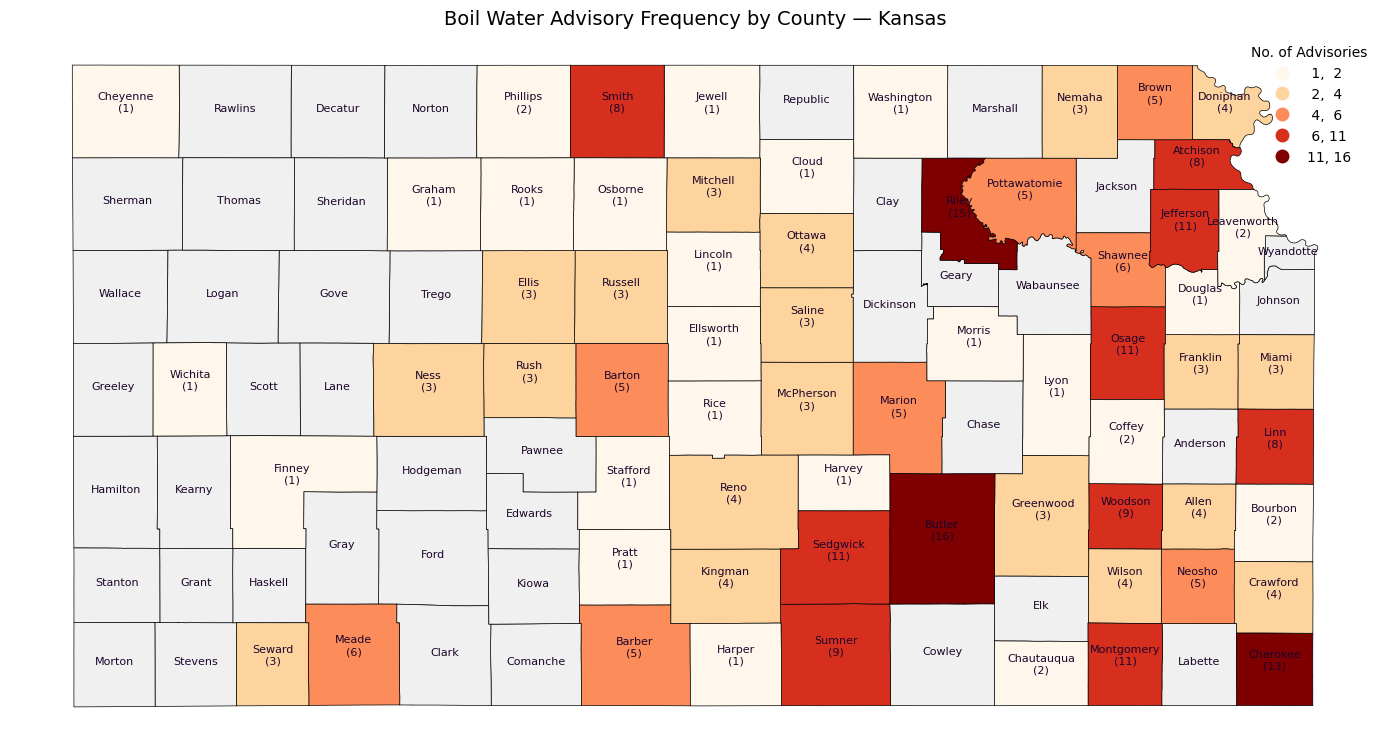

In [41]:
fig, ax = plt.subplots(figsize=(14, 9))

# Zero counties in gray first
ks_map[ks_map["bwa_count"] == 0].plot(
    ax=ax, color="#f0f0f0", edgecolor="black", linewidth=0.5
)
ks_map[ks_map["bwa_count"] > 0].plot(
    ax=ax,
    column="bwa_count",
    cmap="OrRd",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    scheme="NaturalBreaks",
    k=5,
    legend_kwds={"title": "No. of Advisories", "fmt": "{:.0f}", "frameon": False}
)
for _, row in ks_map.iterrows():
    ax.annotate(
        f"{row['NAME']}\n({int(row['bwa_count'])})" if row["bwa_count"] > 0 else row["NAME"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        fontsize=8, ha="center", color="#1b042a"
    )

ax.set_title("Boil Water Advisory Frequency by County — Kansas", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### **Visualizing Adviosry plot by population size in all the counties**
SIMPLE POINT MAP — BWA Locations

In [19]:
bwa_gdf["Population_Served"].max()

np.float64(35126.0)

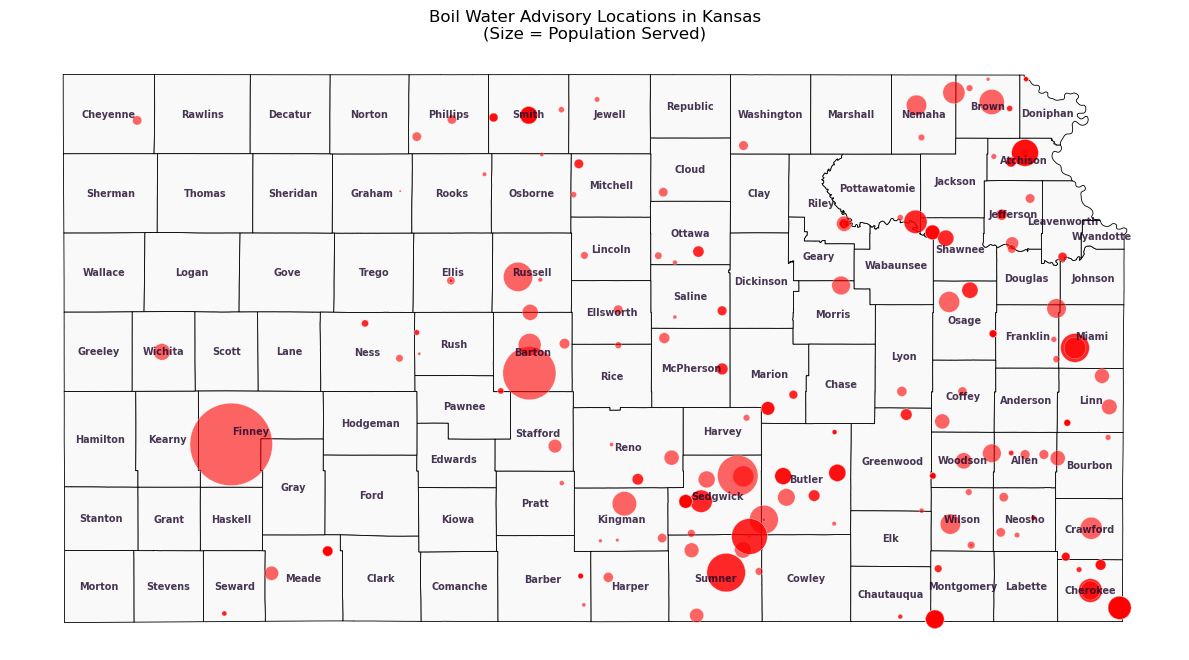

In [40]:
fig, ax = plt.subplots(figsize=(12, 8))

# Base layer as counties map
ks_counties.plot(ax=ax, color="#f9f9f9", edgecolor="black", linewidth=0.6)

# Simple points — all same color, sized by population
bwa_gdf.plot(
    ax=ax,
    color='red',
    markersize=bwa_gdf["Population_Served"].clip(upper=bwa_gdf["Population_Served"].max()) / 10,
    alpha=0.6,
    edgecolor='white',
    linewidth=0.3
)
# ---- ADD COUNTY NAME LABELS (at centroids) ----
for _, row in ks_counties.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row["NAME"],
        xy=(centroid.x, centroid.y),
        fontsize=7,
        ha="center",
        va="center",
        color="#1b042a",
        alpha=0.8,
        fontweight='bold'
    )

ax.set_title("Boil Water Advisory Locations in Kansas\n(Size = Population Served)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()


#### **Visualizing Adviosry plot by population size in all the counties with City/County Labels**
SIMPLE POINT MAP — BWA Locations with City/County Labels

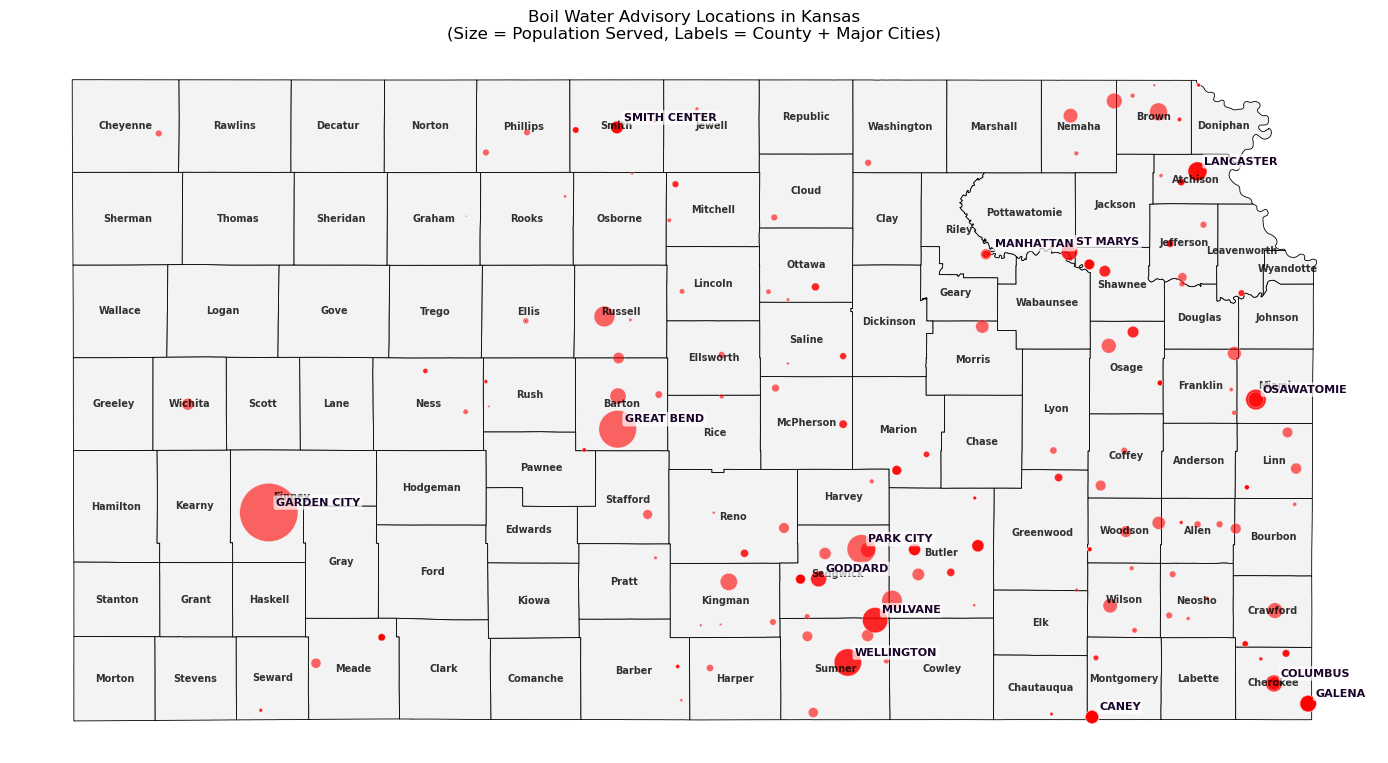

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

# Base layer
ks_counties.plot(ax=ax, color="#f3f3f3", edgecolor="black", linewidth=0.6)

# Simple points — all same color, sized by population
bwa_gdf.plot(
    ax=ax,
    color='red',
    markersize=bwa_gdf["Population_Served_Clean"].clip(upper=bwa_gdf["Population_Served"].max()) / 20,
    alpha=0.6,
    edgecolor='white',
    linewidth=0.3
)

# ---- ADD COUNTY NAME LABELS (at centroids) ----
for _, row in ks_counties.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row["NAME"],
        xy=(centroid.x, centroid.y),
        fontsize=7,
        ha="center",
        va="center",
        color="black",
        alpha=0.8,
        fontweight='bold'
    )

# ---- ADD CITY LABELS (from BWA data) ----
# Get unique cities with their coordinates (use first occurrence)
city_coords = bwa_gdf.groupby('City').agg({
    'lon': 'first',
    'lat': 'first',
    'Population_Served_Clean': 'sum'  # Sum population for label sizing
}).reset_index()

# Only label larger cities (population > 5000) to avoid clutter
major_cities = city_coords[city_coords['Population_Served_Clean'] > 5000]

for _, row in major_cities.iterrows():
    ax.annotate(
        row["City"],
        xy=(row["lon"], row["lat"]),
        xytext=(5, 5),  # Offseting from the spot slightly
        textcoords='offset points',
        fontsize=8,
        ha="left",
        color="#1b042a",
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                  edgecolor='none', alpha=0.7)  # Light background for readability
    )

ax.set_title("Boil Water Advisory Locations in Kansas\n(Size = Population Served, Labels = County + Major Cities)", 
             fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### **Visualization on time basis**
TEMPORAL ANALYSIS — When Do Advisories Occur?

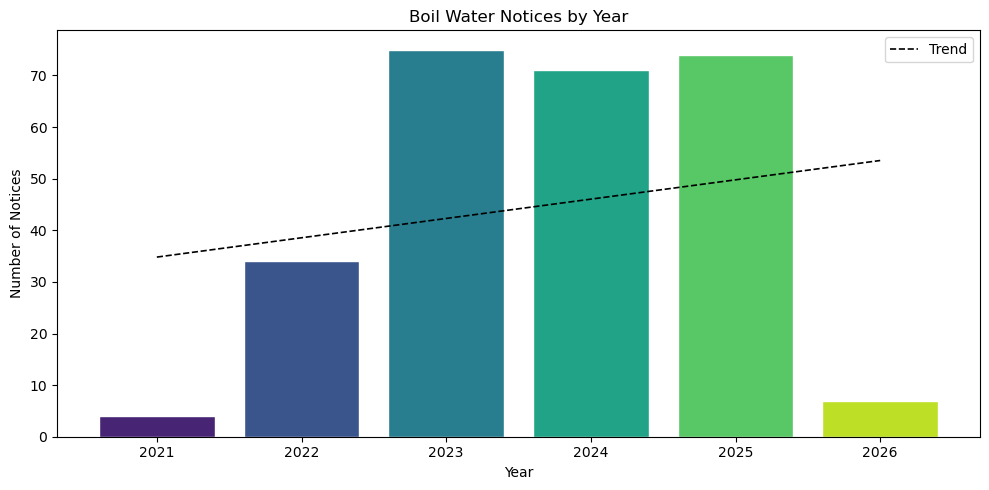

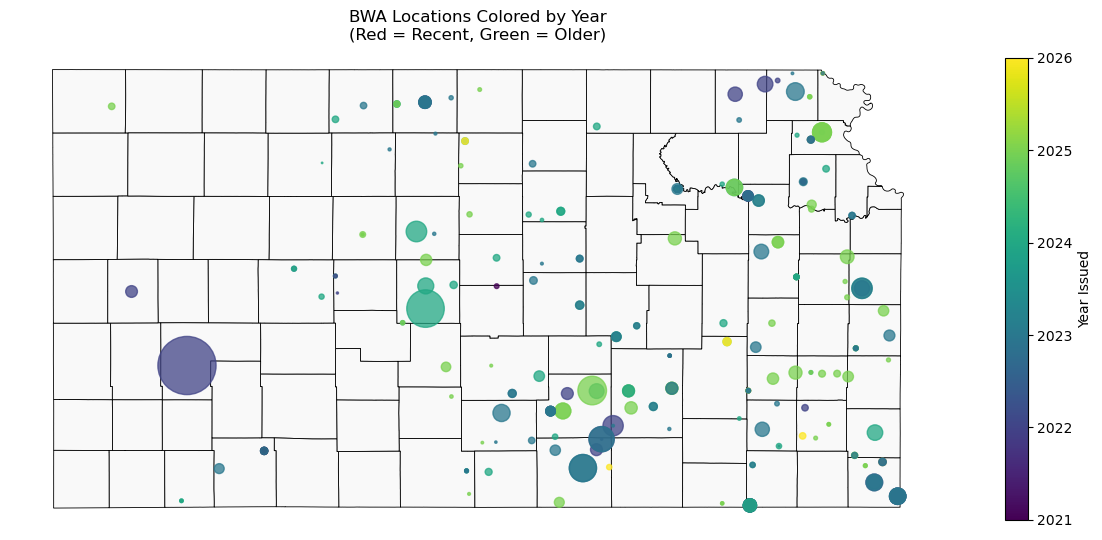

In [55]:
# ---- Bar Chart by Year ----
year_counts = bwa_gdf["Year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
# colors = cm.RdYlGn_r(np.linspace(0.1, 0.9, len(year_counts)))
colors = cm.viridis(np.linspace(0.1, 0.9, len(year_counts)))

bars = ax.bar(year_counts.index, year_counts.values, color=colors, edgecolor="white")

# To plot trend line
z = np.polyfit(year_counts.index, year_counts.values, 1)
p = np.poly1d(z)
ax.plot(year_counts.index, p(year_counts.index), "k--", linewidth=1.2, label="Trend")

ax.set_title("Boil Water Notices by Year", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Notices")
ax.legend()
plt.tight_layout()
plt.show()

# ---- Point Map Colored by Year ----
fig, ax = plt.subplots(figsize=(12, 8))

ks_counties.plot(ax=ax, color="#f9f9f9", edgecolor="black", linewidth=0.6)

bwa_gdf.plot(
    ax=ax,
    column="Year",
    # cmap="RdYlGn_r",
    cmap="viridis",
    markersize=bwa_gdf["Population_Served"].clip(upper=bwa_gdf["Population_Served"].max()) / 20,
    alpha=0.75,
    legend=True,
    legend_kwds={"label": "Year Issued", "shrink": 0.6}
)

ax.set_title("BWA Locations Colored by Year\n(Red = Recent, Green = Older)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### **Visulization of population and advisory**
DISTRIBUTION ANALYSIS — Population & Duration 

C:\Users\aarun\AppData\Local\Temp\ipykernel_29948\3442566457.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_by_year, labels=years, patch_artist=True,


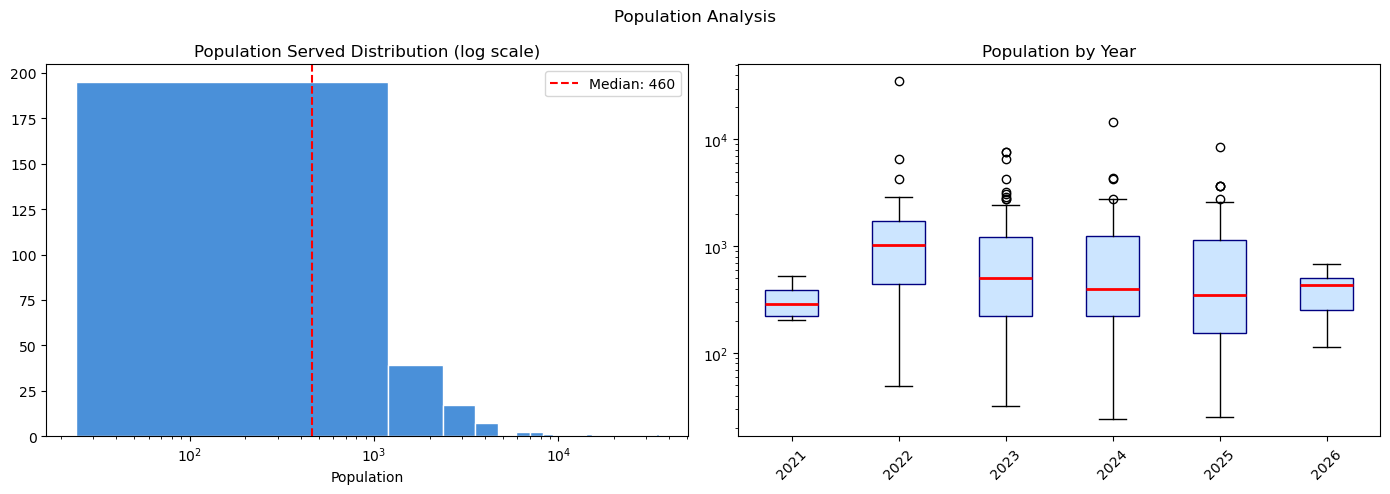

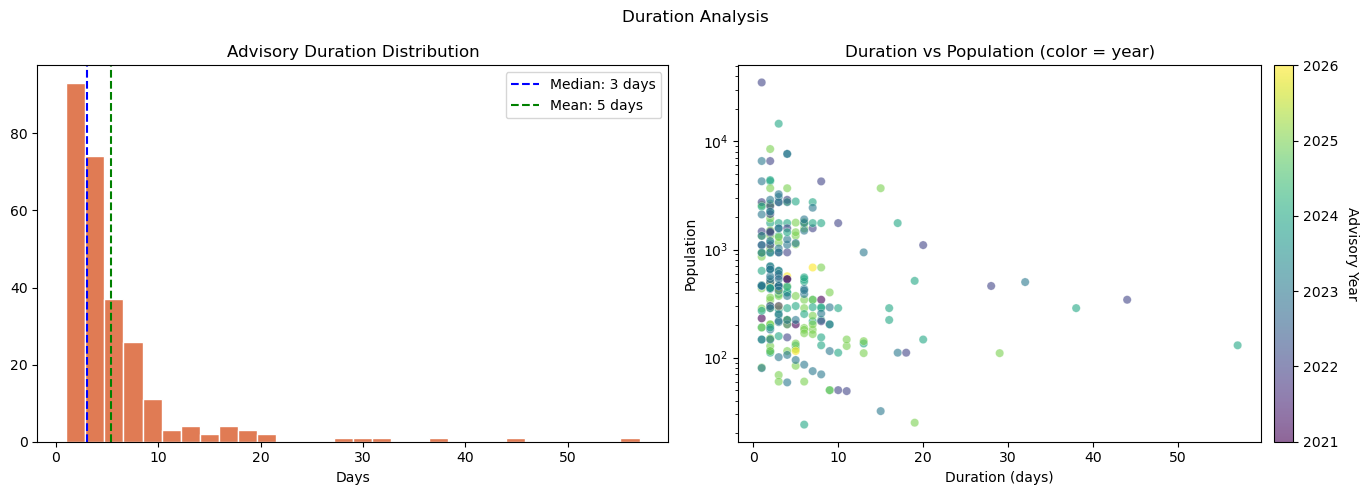

In [69]:
# ---- Population Distribution ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pop = bwa_gdf["Population_Served"].dropna()

axes[0].hist(pop, bins=30, color="#4a90d9", edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_title("Population Served Distribution (log scale)")
axes[0].set_xlabel("Population")
axes[0].axvline(pop.median(), color="red", linestyle="--", label=f"Median: {int(pop.median()):,}")
axes[0].legend()

# Boxplot by year
years = sorted(bwa_gdf["Year"].unique())
data_by_year = [bwa_gdf[bwa_gdf["Year"] == y]["Population_Served_Clean"].dropna() for y in years]

axes[1].boxplot(data_by_year, labels=years, patch_artist=True,
                boxprops=dict(facecolor="#cce5ff", color="navy"),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Population by Year")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Population Analysis", fontsize=12)
plt.tight_layout()
plt.show()

# ---- Duration Analysis ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dur = bwa_gdf["Advisory_Duration"].dropna()

axes[0].hist(dur, bins=30, color="#e07b54", edgecolor="white")
axes[0].axvline(dur.median(), color="blue", linestyle="--", label=f"Median: {int(dur.median())} days")
axes[0].axvline(dur.mean(), color="green", linestyle="--", label=f"Mean: {int(dur.mean())} days")
axes[0].set_title("Advisory Duration Distribution")
axes[0].set_xlabel("Days")
axes[0].legend()

axes[1].scatter(
    dur, 
    bwa_gdf["Population_Served"],
    c=bwa_gdf["Year"],
    cmap="viridis",
    alpha=0.6, edgecolors="white", linewidth=0.3
)
# Add a colorbar with label
cbar = plt.colorbar(axes[1].collections[0], ax=axes[1], pad=0.02)
cbar.set_label("Advisory Year", rotation=270, labelpad=15)


axes[1].set_title("Duration vs Population (color = year)")
axes[1].set_xlabel("Duration (days)")
axes[1].set_ylabel("Population")
axes[1].set_yscale("log")

plt.suptitle("Duration Analysis", fontsize=12)
plt.tight_layout()
plt.show()

#### **SEVERITY INDEX — Composite Risk Metric**

In [71]:
bwa_gdf['severity_index'] = (
    bwa_gdf['Advisory_Duration'] * 
    bwa_gdf['Population_Served'] * 
    bwa_gdf['No._of_Violations']
)

print(f"Severity index range: {bwa_gdf['severity_index'].min():,.0f} to {bwa_gdf['severity_index'].max():,.0f}")
print("\nTop 5 highest severity advisories:")
print(bwa_gdf.nlargest(5, 'severity_index')[['PWS_Name', 'County', 'severity_index']])

# County-level aggregation
county_severity = bwa_gdf.groupby('County').agg({
    'Federal_ID': 'nunique',
    'Advisory_Duration': 'sum',
    'Population_Served': 'sum',
    'No._of_Violations': 'sum',
    'severity_index': 'sum'
})
county_severity.columns = ['systems', 'total_days', 'total_pop', 'total_violations', 'total_severity']
county_severity = county_severity.sort_values('total_severity', ascending=False)

print("\nTop 5 counties by total severity:")
print(county_severity.head())

Severity index range: 560 to 3,283,720

Top 5 highest severity advisories:
                PWS_Name      County  severity_index
45        CANEY, CITY OF  Montgomery       3283720.0
169       CANEY, CITY OF  Montgomery       1931600.0
242  WELLINGTON, CITY OF      Sumner       1808704.0
243  WELLINGTON, CITY OF      Sumner       1808704.0
39        CANEY, CITY OF  Montgomery       1545280.0

Top 5 counties by total severity:
            systems  total_days  total_pop  total_violations  total_severity
County                                                                      
Montgomery        2          80    16388.0              1450      13310800.0
Sumner            7          31    32443.0               347       4492762.0
Miami             2          10    10995.0               188       1823210.0
Cherokee          5          43    23377.0               274       1741374.0
Linn              3          50     3695.0               735       1695967.0
